In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pm25_df = pd.read_csv("../data_final/Table2_1b.csv")
who_df = pd.read_csv("../data_final/b7450f71-eae9-4c95-98e4-022ddec4a93f.csv")
emissions_df = pd.read_csv("../data_final/fig03_particulate_matter_annual_emissions.csv")

print(pm25_df.head())
print(who_df.head())
print(emissions_df.head())

  Table 2.1b: Annual Mean Concentrations of PM2.5 in the UK at urban background monitoring sites, 2009 to 2024  \
0              [z] is shorthand for 'Not Applicable'                                                             
1                                               Year                                                             
2                                               2009                                                             
3                                               2010                                                             
4                                               2011                                                             

         Unnamed: 1                                       Unnamed: 2  \
0               NaN                                              NaN   
1              Site  Annual Mean PM2.5 concentration (µg/m3)[note 1]   
2  All sites (mean)                                 12.3933081899161   
3  All sites (mean)        

In [2]:
import hashlib

def get_hash(path):
    with open(path, "rb") as f:
        return hashlib.sha256(f.read()).hexdigest()

print(get_hash("../data_final/Table2_1b.csv"))
print(get_hash("../data_final/b7450f71-eae9-4c95-98e4-022ddec4a93f.csv"))
print(get_hash("../data_final/fig03_particulate_matter_annual_emissions.csv"))

91bb9a120363c63607e85a5b7239e5c19734544477901f2b08ace08cc5473e63
547fc92212ae6e3e8f04f80e0e8b25bbf92a2892fa12e990786fe6344639443c
1078586776fba72123f23bd0c6723ad8befb63ef7132c23497bca7fd44db2bbf


In [3]:
pm25_df.head()

,"Table 2.1b: Annual Mean Concentrations of PM2.5 in the UK at urban background monitoring sites, 2009 to 2024",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,[z] is shorthand for 'Not Applicable',NaN,NaN,NaN,NaN,NaN
1,Year,Site,Annual Mean PM2.5 concentration (µg/m3)[note 1],95% confidence interval for 'All sites' (+/-)[...,Data capture (%),Measurement Frequency[note 4]
2,2009,All sites (mean),12.3933081899161,0.626062170751266,[z],[z]
3,2010,All sites (mean),12.9730330496344,0.812720694156802,[z],[z]
4,2011,All sites (mean),13.7048403424797,0.893151641790071,[z],[z]


In [4]:
pm25_clean = pm25_df.iloc[2:].copy()
pm25_clean.columns = [
    "year",
    "site",
    "pm25_concentration",
    "confidence_interval",
    "data_capture",
    "measurement_frequency",
]
pm25_clean = pm25_clean[["year", "site","pm25_concentration"]].dropna()

In [5]:
pm25_clean.head()

,year,site,pm25_concentration
2,2009,All sites (mean),12.3933081899161
3,2010,All sites (mean),12.9730330496344
4,2011,All sites (mean),13.7048403424797
5,2012,All sites (mean),12.5614728524452
6,2013,All sites (mean),12.0871967621022


In [6]:
emissions_df.head()

,series,year,emissions (thousand tonnes)
0,PM10,1970,689.444181
1,PM10,1971,634.162134
2,PM10,1972,560.969478
3,PM10,1973,584.853938
4,PM10,1974,531.686350


In [7]:
emissions_clean = emissions_df[emissions_df["series"] == "PM2.5"].copy()
emissions_clean = emissions_clean[["series","year", "emissions (thousand tonnes)"]].dropna()

emissions_clean.head()

,series,year,emissions (thousand tonnes)
55,PM2.5,1970,545.786787
56,PM2.5,1971,483.834732
57,PM2.5,1972,424.825260
58,PM2.5,1973,432.199186
59,PM2.5,1974,400.967193


In [8]:
print(pm25_clean.head())
print(emissions_clean.head())

   year              site pm25_concentration
2  2009  All sites (mean)   12.3933081899161
3  2010  All sites (mean)   12.9730330496344
4  2011  All sites (mean)   13.7048403424797
5  2012  All sites (mean)   12.5614728524452
6  2013  All sites (mean)   12.0871967621022
   series  year  emissions (thousand tonnes)
55  PM2.5  1970                   545.786787
56  PM2.5  1971                   483.834732
57  PM2.5  1972                   424.825260
58  PM2.5  1973                   432.199186
59  PM2.5  1974                   400.967193


In [9]:
print("PM25 / air data")
print(pm25_df.columns)
print(pm25_df.dtypes)
print(pm25_df.head())

print("\nWHO data")
print(who_df.columns)
print(who_df.dtypes)
print(who_df.head())

print("\nEmissions data")
print(emissions_df.columns)
print(emissions_df.dtypes)
print(emissions_df.head())

PM25 / air data
Index(['Table 2.1b: Annual Mean Concentrations of PM2.5 in the UK at urban background monitoring sites, 2009 to 2024',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5'],
      dtype='object')
Table 2.1b: Annual Mean Concentrations of PM2.5 in the UK at urban background monitoring sites, 2009 to 2024    object
Unnamed: 1                                                                                                      object
Unnamed: 2                                                                                                      object
Unnamed: 3                                                                                                      object
Unnamed: 4                                                                                                      object
Unnamed: 5                                                                                                      object
dtype: object
  Table 2.1b: Annual Mean Concentrati

In [10]:
print(pm25_df.shape)
print(who_df.shape)
print(emissions_df.shape)

(828, 6)
(180, 34)
(120, 3)


In [11]:
pm25_clean = pm25_df.iloc[2:, [0, 1, 2]].copy()
pm25_clean.columns = ["year", "site", "pm25_concentration"]
pm25_clean["year"] = pd.to_numeric(pm25_clean["year"], errors="coerce")
pm25_clean["pm25_concentration"] = pd.to_numeric(pm25_clean["pm25_concentration"], errors="coerce")
pm25_clean = pm25_clean.dropna(subset=["year", "pm25_concentration"])
pm25_clean["year"] = pm25_clean["year"].astype(int)

pm25_clean.head()

,year,site,pm25_concentration
2,2009,All sites (mean),12.393308
3,2010,All sites (mean),12.973033
4,2011,All sites (mean),13.704840
5,2012,All sites (mean),12.561473
6,2013,All sites (mean),12.087197


In [12]:
who_clean = who_df[["Period", "Location", "Indicator", "FactValueNumeric"]].copy()
who_clean.columns = ["year", "location", "indicator", "mortality_value"]
who_clean["year"] = pd.to_numeric(who_clean["year"], errors="coerce")
who_clean["mortality_value"] = pd.to_numeric(who_clean["mortality_value"], errors="coerce")
who_clean = who_clean.dropna(subset=["year", "mortality_value"])
who_clean["year"] = who_clean["year"].astype(int)

who_clean.head()

,year,location,indicator,mortality_value
0,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,10361.0
1,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,11234.0
2,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,11972.0
3,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,1208.0
4,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,1286.0


In [13]:
emissions_clean = emissions_df.copy()
emissions_clean.columns = ["pollutant", "year", "emissions_thousand_tonnes"]
emissions_clean["year"] = pd.to_numeric(emissions_clean["year"], errors="coerce")
emissions_clean["emissions_thousand_tonnes"] = pd.to_numeric(
    emissions_clean["emissions_thousand_tonnes"], errors="coerce"
)
emissions_clean = emissions_clean.dropna(subset=["year", "emissions_thousand_tonnes"])
emissions_clean["year"] = emissions_clean["year"].astype(int)

emissions_clean.head()

,pollutant,year,emissions_thousand_tonnes
0,PM10,1970,689.444181
1,PM10,1971,634.162134
2,PM10,1972,560.969478
3,PM10,1973,584.853938
4,PM10,1974,531.686350


In [14]:
who_df[["Dim1", "Dim2", "Value"]].drop_duplicates().sort_values(["Dim1", "Dim2"]).head(30)

,Dim1,Dim2,Value
13,Both sexes,Acute lower respiratory infections,4085 [1349-7951]
31,Both sexes,Acute lower respiratory infections,4260 [1481-8045]
49,Both sexes,Acute lower respiratory infections,4166 [1452-7868]
67,Both sexes,Acute lower respiratory infections,4031 [1414-7555]
85,Both sexes,Acute lower respiratory infections,4749 [1789-8620]
103,Both sexes,Acute lower respiratory infections,4006 [1497-7308]
122,Both sexes,Acute lower respiratory infections,4252 [1699-7491]
139,Both sexes,Acute lower respiratory infections,4240 [1705-7427]
157,Both sexes,Acute lower respiratory infections,4474 [1940-7580]
175,Both sexes,Acute lower respiratory infections,4502 [1929-7643]


In [15]:
print(who_df["Dim1"].dropna().unique()[:20])
print(who_df["Dim2"].dropna().unique()[:20])
print(who_df["Location"].dropna().unique()[:20])
print(pm25_clean["site"].dropna().unique()[:20])
print(emissions_clean["pollutant"].dropna().unique())

['Female' 'Both sexes' 'Male']
['All causes' 'Ischaemic heart disease'
 'Chronic obstructive pulmonary disease' 'Stroke'
 'Trachea, bronchus, lung cancers' 'Acute lower respiratory infections']
['United Kingdom of Great Britain and Northern Ireland']
['All sites (mean)' 'Aberdeen' 'Aberdeen Erroll Park' 'Barnsley Gawber'
 'Belfast Centre' 'Birmingham Acocks Green' 'Birmingham Ladywood'
 'Birmingham Tyburn' 'Blackburn Audley Park' 'Blackpool Marton'
 'Borehamwood Meadow Park' 'Bournemouth' 'Brighton Preston Park'
 "Bristol St Paul's" 'Burton-on-Trent Horninglow' 'Canterbury'
 'Cardiff Centre' 'Chesterfield' 'Chesterfield Loundsley Green'
 'Coventry Allesley']
['PM10' 'PM2.5' 'erc_2020-2029']


In [16]:
pm25_uk = pm25_clean[pm25_clean["site"] == "All sites (mean)"].copy()

who_uk = who_df[
    (who_df["Location"] == "United Kingdom of Great Britain and Northern Ireland") &
    (who_df["Dim1"] == "Both sexes") &
    (who_df["Dim2"] == "All causes")
][["Period", "Location", "Indicator", "FactValueNumeric"]].copy()

who_uk.columns = ["year", "location", "indicator", "mortality_value"]
who_uk["year"] = pd.to_numeric(who_uk["year"], errors="coerce")
who_uk["mortality_value"] = pd.to_numeric(who_uk["mortality_value"], errors="coerce")
who_uk = who_uk.dropna(subset=["year", "mortality_value"])
who_uk["year"] = who_uk["year"].astype(int)

emissions_pm25 = emissions_clean[
    emissions_clean["pollutant"] == "PM2.5"
].copy()

In [17]:
pm25_uk["geography"] = "United Kingdom"
who_uk["geography"] = "United Kingdom"
emissions_pm25["geography"] = "United Kingdom"

In [18]:
pm25_uk = pm25_uk[["year", "geography", "pm25_concentration"]]
who_uk = who_uk[["year", "geography", "mortality_value"]]
emissions_pm25 = emissions_pm25[["year", "geography", "emissions_thousand_tonnes"]]

In [19]:
#How has all-cause mortality changed over time in the UK?
who_uk = who_clean[
    (who_clean["location"] == "United Kingdom of Great Britain and Northern Ireland")
].copy() #Creates a copy of the cleaned dataset, with location set to UK

who_uk = who_uk.sort_values("year") #Sorts values by year

who_by_year = (
    who_uk
    .groupby("year")["mortality_value"]
    .mean()
    .reset_index()
) #Groupby year and find the mean mortality value for each year (This is dataset only has 2010-2019)

who_by_year

,year,mortality_value
0,2010,7067.850000
1,2011,6622.716667
2,2012,6393.000000
3,2013,6311.405556
4,2014,5746.188889
5,2015,6055.966667
6,2016,5442.044444
7,2017,5350.500000
8,2018,5270.433333
9,2019,4962.916667


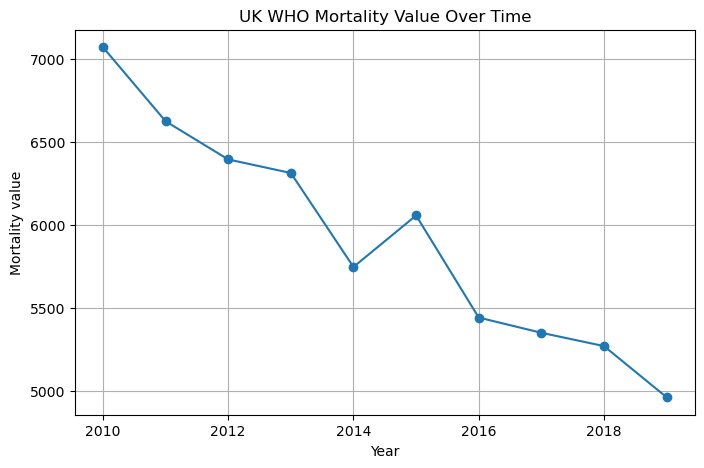

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(who_by_year["year"], who_by_year["mortality_value"], marker="o")
plt.title("UK WHO Mortality Value Over Time")
plt.xlabel("Year")
plt.ylabel("Mortality value")
plt.grid(True)
plt.show()

In [21]:
emissions_without_extra = emissions_clean[
    emissions_clean["pollutant"].isin(["PM10", "PM2.5"])
].copy() 
#Copys clean emission data, excludes the extra rows containing "erc_2020-2029", 
#this was a single value repeated for each year. My best guess is that it is a placeholder for 2020-2029 and not actually observed emissions

emissions_2010_2019 = emissions_without_extra[
    (emissions_clean["year"] >= 2010) &
    (emissions_clean["year"] <= 2019)
].copy() #Only filtered to 2019 to keep in line with the WHO data and avoid this extra placeholder

emissions_2010_2019.head()

emissions_by_year = (
    emissions_2010_2019
    .groupby("year")["emissions_thousand_tonnes"]
    .sum()
    .reset_index()
) #Groupby year for graphing

emissions_by_year.head(20)

/var/folders/s0/sb498m3j5pq3p85ywy45wdpm0000gn/T/ipykernel_25146/1435426054.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  emissions_2010_2019 = emissions_without_extra[


,year,emissions_thousand_tonnes
0,2010,221.632531
1,2011,210.306937
2,2012,205.749299
3,2013,209.127888
4,2014,202.346940
5,2015,199.337857
6,2016,195.169813
7,2017,198.329625
8,2018,197.210476
9,2019,187.388840


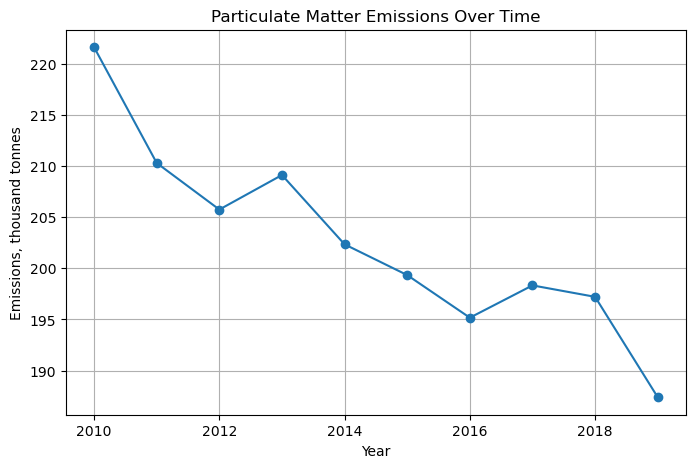

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(
    emissions_by_year["year"],
    emissions_by_year["emissions_thousand_tonnes"],
    marker="o"
)

plt.title("Particulate Matter Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("Emissions, thousand tonnes")
plt.grid(True)
plt.show()

In [23]:

#Copys clean emission data, excludes the extra rows containing "erc_2020-2029", 
#this was a single value repeated for each year. My best guess is that it is a placeholder for 2020-2029 and not actually observed emissions

pm25_concentration_2010_2019 = pm25_uk[
    (pm25_uk["year"] >= 2010) &
    (pm25_uk["year"] <= 2019)
].copy() #Only filtered to 2019 to keep in line with the WHO data and avoid this extra placeholder

pm25_concentration_2010_2019.head()

concentrations_by_year = (
    pm25_concentration_2010_2019
    .groupby("year")["pm25_concentration"]
    .sum()
    .reset_index()
) #Groupby year for graphing

concentrations_by_year.head(20)

,year,pm25_concentration
0,2010,12.973033
1,2011,13.704840
2,2012,12.561473
3,2013,12.087197
4,2014,12.079755
5,2015,9.771606
6,2016,9.789564
7,2017,9.414699
8,2018,9.925692
9,2019,9.880706


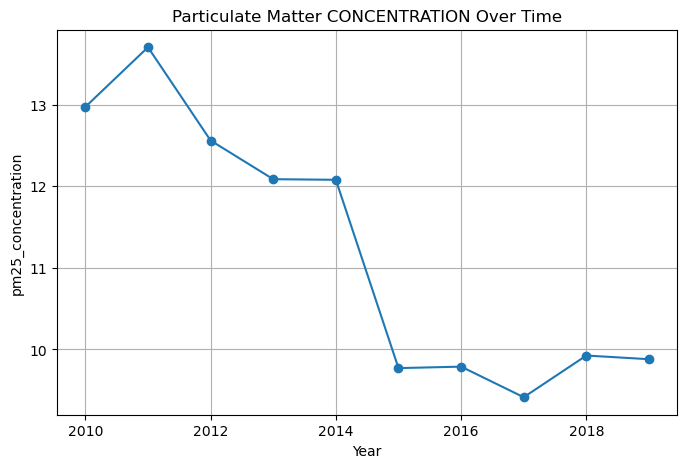

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(
    concentrations_by_year["year"],
    concentrations_by_year["pm25_concentration"],
    marker="o"
)

plt.title("Particulate Matter CONCENTRATION Over Time")
plt.xlabel("Year")
plt.ylabel("pm25_concentration")
plt.grid(True)
plt.show()

In [25]:
pm25_emissions_concentration = pm25_uk.merge(
    emissions_pm25,
    on="year",
    how="inner"
)#Combining emissions and concentration datasets

In [26]:
pm25_emissions_concentration.head()

,year,geography_x,pm25_concentration,geography_y,emissions_thousand_tonnes
0,2009,United Kingdom,12.393308,United Kingdom,78.406993
1,2010,United Kingdom,12.973033,United Kingdom,79.993241
2,2011,United Kingdom,13.704840,United Kingdom,76.145328
3,2012,United Kingdom,12.561473,United Kingdom,75.935942
4,2013,United Kingdom,12.087197,United Kingdom,75.844929


In [27]:
pm25_emissions_concentration[
    ["pm25_concentration", "emissions_thousand_tonnes"]
].corr() #Correlation between concentration and emissions

,pm25_concentration,emissions_thousand_tonnes
pm25_concentration,1.00000,0.95106
emissions_thousand_tonnes,0.95106,1.00000


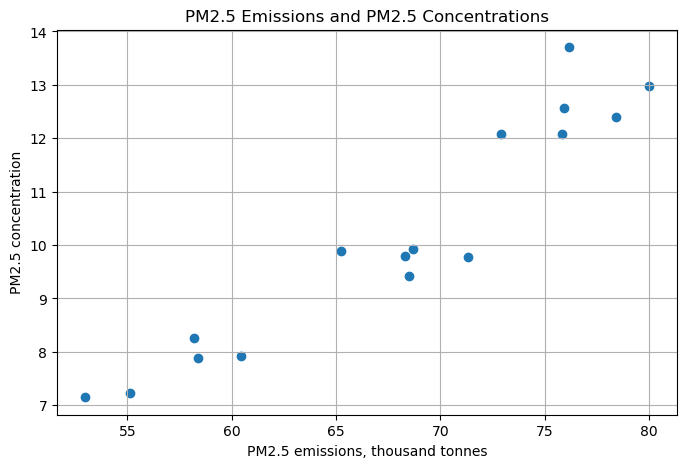

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(
    pm25_emissions_concentration["emissions_thousand_tonnes"],
    pm25_emissions_concentration["pm25_concentration"]
)

plt.title("PM2.5 Emissions and PM2.5 Concentrations")
plt.xlabel("PM2.5 emissions, thousand tonnes")
plt.ylabel("PM2.5 concentration")
plt.grid(True)
plt.show()